<a href="https://colab.research.google.com/github/u21740012/COS-783-Project/blob/main/Image_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/u21740012/COS-783-Project.git

fatal: destination path 'COS-783-Project' already exists and is not an empty directory.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import matplotlib.pyplot as plt

train_dir = 'COS-783-Project/data/TRAINING_CG-1050/TRAINING'
val_dir = 'COS-783-Project/data/VALIDATION_CG-1050/VALIDATION'

IMG_SIZE = (224, 224)
BATCH_SIZE = 64

# Data Generators
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)
val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)

# Double-check the class mappings to be absolutely sure
print("Class indices:", train_generator.class_indices)

Found 1460 images belonging to 2 classes.
Found 628 images belonging to 2 classes.
Class indices: {'ORIGINAL': 0, 'TAMPERED': 1}


In [7]:
base_model = tf.keras.applications.ResNet50V2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = True

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision')]
)

In [8]:
callbacks = [
    # Automatically lowers learning rate when validation loss stalls
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    # Stops training early if the model starts severely overfitting
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)
]

In [9]:
history = model.fit(
    train_generator,
    epochs=15, # Gave it a few more epochs since callbacks will stop it if it breaks
    validation_data=val_generator,
    callbacks=callbacks
)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 128s 3s/step - accuracy: 0.5075 - loss: 0.9433 - precision: 0.5075 - val_accuracy: 0.5510 - val_loss: 0.7367 - val_precision: 0.5500 - learning_rate: 1.0000e-05
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.5610 - loss: 0.8532 - precision: 0.5631 - val_accuracy: 0.5764 - val_loss: 0.7091 - val_precision: 0.5714 - learning_rate: 1.0000e-05
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.5829 - loss: 0.8057 - precision: 0.5823 - val_accuracy: 0.6019 - val_loss: 0.6901 - val_precision: 0.5930 - learning_rate: 1.0000e-05
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.5637 - loss: 0.8066 - precision: 0.5673 - val_accuracy: 0.6115 - val_loss: 0.6749 - val_precision: 0.6054 - learning_rate: 1.0000e-05
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.6089 - loss: 0.7222 - precision: 0.6100 - val_accuracy: 0.6162 - val_loss: 0.6670 - val_precision: 0.6083 - learning_rate: 1.0000e-05
Epoch 6/1

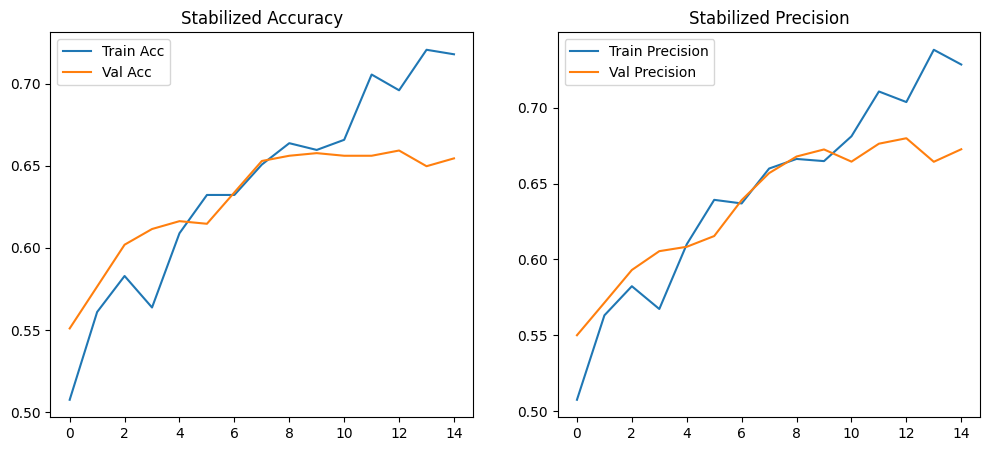

In [10]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Stabilized Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['precision'], label='Train Precision')
plt.plot(history.history['val_precision'], label='Val Precision')
plt.title('Stabilized Precision')
plt.legend()
plt.show()

In [ ]:
import os
os.makedirs('COS-783-Project/models', exist_ok=True)
model.save('COS-783-Project/models/tampering_detector.keras')
print('Model saved to COS-783-Project/models/tampering_detector.keras')